In [32]:
import sqlite3
import pandas as pd

In [33]:
query = '''
SELECT *
FROM employees
WHERE vacation_hours > 40;
'''
with sqlite3.connect('employees.db') as conn:
    df = pd.read_sql_query(query, conn)

df['customer_id'] = pd.to_numeric(df['customer_id'])
df.head()


,customer_id,email_address,vacation_hours,sallaried,title
0,2,keith0@adventure-works.com,80,1,manager
1,3,donna0@adventure-works.com,69,1,sales rep
2,4,janet1@adventure-works.com,49,1,sales rep
3,5,lucy0@adventure-works.com,49,1,sales rep
4,6,rosmarie0@adventure-works.com,88,1,manager


In [34]:
df['employee_name'] = df['email_address'].str.extract(r'([a-z]+)(?=\d)')
df.to_excel('out/employees_with_high_vaca_hours.xlsx', index=False)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     554 non-null    int64 
 1   email_address   554 non-null    object
 2   vacation_hours  554 non-null    int64 
 3   sallaried       554 non-null    int64 
 4   title           554 non-null    object
 5   employee_name   554 non-null    object
dtypes: int64(3), object(3)
memory usage: 26.1+ KB


HR Question 2

In [35]:
query = '''
SELECT *
FROM employees
'''
with sqlite3.connect('employees.db') as conn:
    employee_df = pd.read_sql_query(query, conn)

employee_df.head()

,customer_id,email_address,vacation_hours,sallaried,title
0,1,orlando0@adventure-works.com,18,0,sales rep
1,2,keith0@adventure-works.com,80,1,manager
2,3,donna0@adventure-works.com,69,1,sales rep
3,4,janet1@adventure-works.com,49,1,sales rep
4,5,lucy0@adventure-works.com,49,1,sales rep


In [36]:
employee_df_grouped = employee_df.groupby(['sallaried', 'title']).mean('vacation_hours')
employee_df_grouped.head()
employee_df.to_excel('out/avg_PTO.xlsx', index=False)

HR Question 3

In [37]:
customer_sales_orders_table = pd.read_csv('customer_sales_orders_tables.csv')
query = '''
SELECT SalesOrderID, OrderQty
FROM SalesOrderDetail
'''
with sqlite3.connect('AdventureWorks.db') as conn:
    sales_order_qty = pd.read_sql_query(query, conn)

sales_order_qty_total = sales_order_qty.groupby('SalesOrderID')['OrderQty'].sum()

employee_id_separated_qty = pd.merge(customer_sales_orders_table, sales_order_qty_total, right_on='SalesOrderID', left_on='sales_order_ids')

employee_id_total_qty = employee_id_separated_qty.groupby('customer_rep_ids')['OrderQty'].sum()
employee_id_total_qty.head()

customer_rep_ids
29486    173
29492    582
29494    173
29496    217
29499    173
Name: OrderQty, dtype: int64

In [38]:
employee_name_qty = pd.merge(df, employee_id_total_qty, left_on='customer_id', right_on='customer_rep_ids')
print(employee_name_qty.sample(10))
employee_name_qty.to_excel('out/total_sales_by_rep.xlsx', index=False)

     customer_id                 email_address  vacation_hours  sallaried  \
9          29523     john6@adventure-works.com              75          0   
23         29571  gabriel0@adventure-works.com              88          1   
138        29918     kirk2@adventure-works.com              93          0   
112        29857   janice1@adventure-works.com              93          1   
72         29734    jauna0@adventure-works.com              86          0   
8          29521      tom1@adventure-works.com              86          1   
97         29810     jean1@adventure-works.com              87          1   
46         29653      pei0@adventure-works.com              85          1   
5          29510    cecil0@adventure-works.com              64          0   
96         29809    kerim0@adventure-works.com              93          0   

         title employee_name  OrderQty  
9      manager          john       197  
23   sales rep       gabriel        76  
138  sales rep          kirk 

## Marketing Questions

In [39]:
query = '''
SELECT c.FirstName || ' ' || LastName AS FullName
FROM Customer AS c
WHERE c.CustomerID IN (
    SELECT s.CustomerID
    FROM SalesOrderHeader AS s
)
'''
with sqlite3.connect('AdventureWorks.db') as conn:
    customers_df = pd.read_sql_query(query, conn)

customers_df.to_excel('out/customers_for_month.xlsx', index=False)


In [40]:
query = '''
SELECT
    CASE
        WHEN c.CompanyName != "" THEN 1
        ELSE 0
    END AS Company,
    AVG(s.SubTotal),
    COUNT(c.CustomerID)
FROM Customer AS c
JOIN SalesOrderHeader AS s
    ON s.CustomerID = c.CustomerID
GROUP BY Company
'''
with sqlite3.connect('AdventureWorks.db') as conn:
    avg_order_company = pd.read_sql_query(query, conn)

avg_order_company.to_excel('out/avg_order_company.xlsx', index=False)


## Sales Quetion 1

In [41]:
query = '''
SELECT count(SalesOrderID) as "Count", sum(SubTotal), Status
FROM SalesOrderHeader
where status = 5;
'''
with sqlite3.connect('AdventureWorks.db') as conn:
    shipped_df = pd.read_sql_query(query, conn)

shipped_df.to_excel('out/Sales_Shipped.xlsx', index=False)


## Sales Question 2

In [42]:
query = '''
select customer.CompanyName, sum(salesorderdetail.OrderQty)
from Customer
join SalesOrderHeader
     on customer.CustomerID = SalesOrderheader.CustomerID
join SalesOrderDetail
     on salesorderdetail.SalesOrderID = SalesOrderHeader.SalesOrderID
group by customer.CompanyName    
Having sum(salesorderdetail.OrderQty) > 1;

'''
with sqlite3.connect('AdventureWorks.db') as conn:
    sales_order_qty_df = pd.read_sql_query(query, conn)

sales_order_qty_df.to_excel('out/Company_Qty.xlsx', index=False)

## Advanced questions

<Axes: xlabel='Category'>

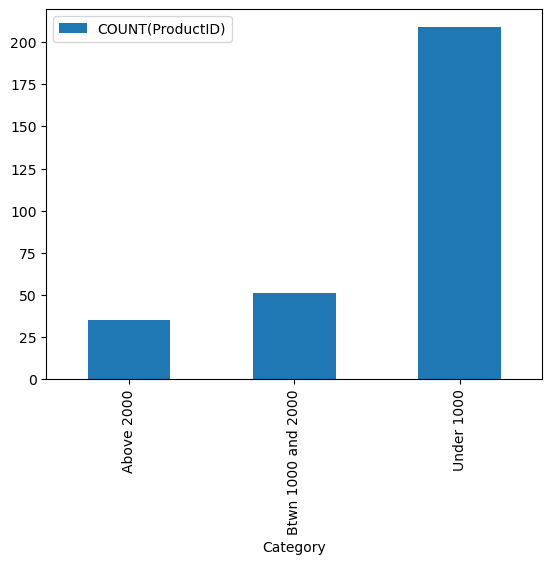

In [43]:
query = '''
SELECT COUNT(ProductID),
CASE WHEN ListPrice < 1000 THEN 'Under 1000'
WHEN ListPrice BETWEEN 1000 AND 2000 THEN 'Btwn 1000 and 2000'
ELSE 'Above 2000'
END AS Category
FROM Product
GROUP BY Category;
'''

with sqlite3.connect('AdventureWorks.db') as conn:
    prod_category_count = pd.read_sql_query(query, conn)

prod_category_count.plot(kind='bar', x= 'Category')

<Axes: xlabel='sallaried'>

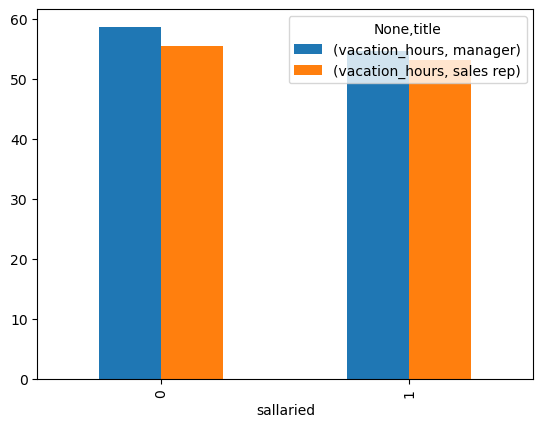

In [44]:

employee_df_grouped = employee_df_grouped.unstack()
employee_df_grouped.plot(kind='bar')

In [45]:
employee_df_grouped.index = ['No', 'Yes']

<Axes: >

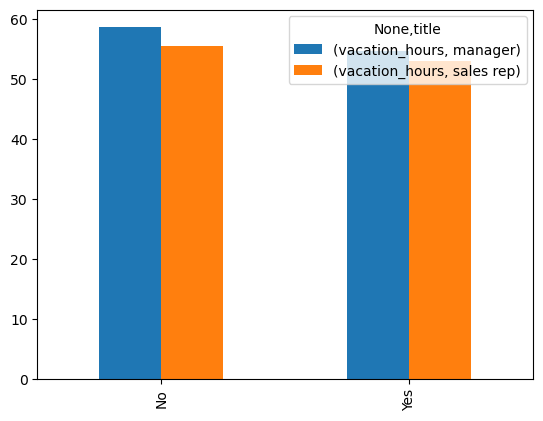

In [46]:
employee_df_grouped.plot(kind='bar')